# Common SymPy Loops for Research Physics

**Plain-English guide.** Every pattern here comes up constantly in physics research:  
looping over constants, differentiating families of functions, expanding series, solving equations, then  
handing the result to NumPy/Torch for fast vectorized evaluation.

Coverage: `c` (speed of light), `C` (Coulomb constant), `ħ`, `k_B`, `e`, `ε₀`, `μ₀`, and the equations that use them.

In [1]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})
print('ready')

ready


---
## Pattern 1 — Loop over fundamental constants

**Plain English:** physics is full of named constants — `c`, `ħ`, `k_B`, `e`, `ε₀`, `μ₀`, `G`.  
SymPy lets you declare them as symbols, then loop over them to print their names, units, and SI values side-by-side.  
This is the foundation of every dimensional-analysis check.

Symbol   SI value       Meaning
----------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Coulomb constant  k_e = 1/(4π ε₀) = 8.9877e+09 N m² C⁻²


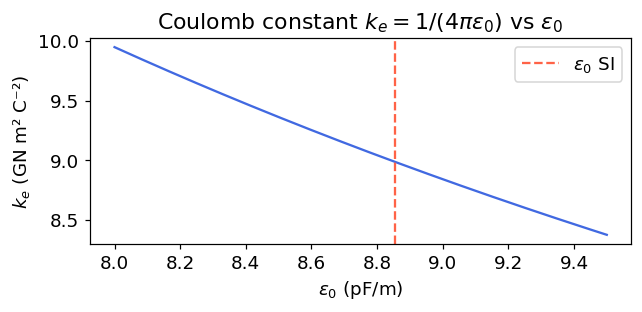

In [2]:
from IPython.display import display, Math

# ── declare all symbols ────────────────────────────────────────────────
c, hbar, k_B, e, eps0, mu0, G = sp.symbols(
    'c hbar k_B e epsilon_0 mu_0 G', positive=True
)
# Coulomb constant  k_e = 1/(4π ε₀)
k_e = 1 / (4 * sp.pi * eps0)

# ── table: (sympy symbol, latex name, SI value, units) ────────────────
constants = [
    (c,    r'c',           2.998e8,   r'\mathrm{m\,s^{-1}}',  'speed of light'),
    (hbar, r'\hbar',       1.055e-34, r'\mathrm{J\cdot s}',   'reduced Planck'),
    (k_B,  r'k_B',         1.381e-23, r'\mathrm{J\,K^{-1}}',  'Boltzmann'),
    (e,    r'e',           1.602e-19, r'\mathrm{C}',           'elementary charge'),
    (eps0, r'\epsilon_0',  8.854e-12, r'\mathrm{C^2\,N^{-1}\,m^{-2}}', 'permittivity'),
    (mu0,  r'\mu_0',       1.257e-6,  r'\mathrm{N\,A^{-2}}',  'permeability'),
    (G,    r'G',           6.674e-11, r'\mathrm{m^3\,kg^{-1}\,s^{-2}}','gravitation'),
]

print(f'{"Symbol":8} {"SI value":14} {"Meaning"}')
print('-'*52)
for sym, latex_name, val, units, meaning in constants:
    display(Math(rf'{latex_name} = {val:.3e}\;{units}\quad\text{{({meaning})}}'  ))

# ── quick derived: Coulomb constant C (k_e) ───────────────────────────
k_e_val = 1 / (4 * np.pi * 8.854e-12)
print(f'\nCoulomb constant  k_e = 1/(4π ε₀) = {k_e_val:.4e} N m² C⁻²')

# ── vectorize: compute k_e for a range of ε₀ perturbations ──────────
eps_range = np.linspace(8.0e-12, 9.5e-12, 200)
k_e_range = 1 / (4 * np.pi * eps_range)

plt.figure(figsize=(6,3))
plt.plot(eps_range * 1e12, k_e_range * 1e-9, color='royalblue')
plt.axvline(8.854, color='tomato', ls='--', label=r'$\epsilon_0$ SI')
plt.xlabel(r'$\epsilon_0$ (pF/m)'); plt.ylabel(r'$k_e$ (GN m² C⁻²)')
plt.title(r'Coulomb constant $k_e = 1/(4\pi\epsilon_0)$ vs $\epsilon_0$')
plt.legend(); plt.tight_layout(); plt.show()

---
## Pattern 2 — Loop over a family of physics equations, differentiate each

**Plain English:** you often have a list of potentials or energies (gravitational, Coulomb, harmonic, Yukawa) and  
need the force $F = -dV/dr$ for each.  Loop with SymPy → get all forces in one cell,  
then `lambdify` to vectorize over a distance array.

Force F = −dV/dr for each potential:



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

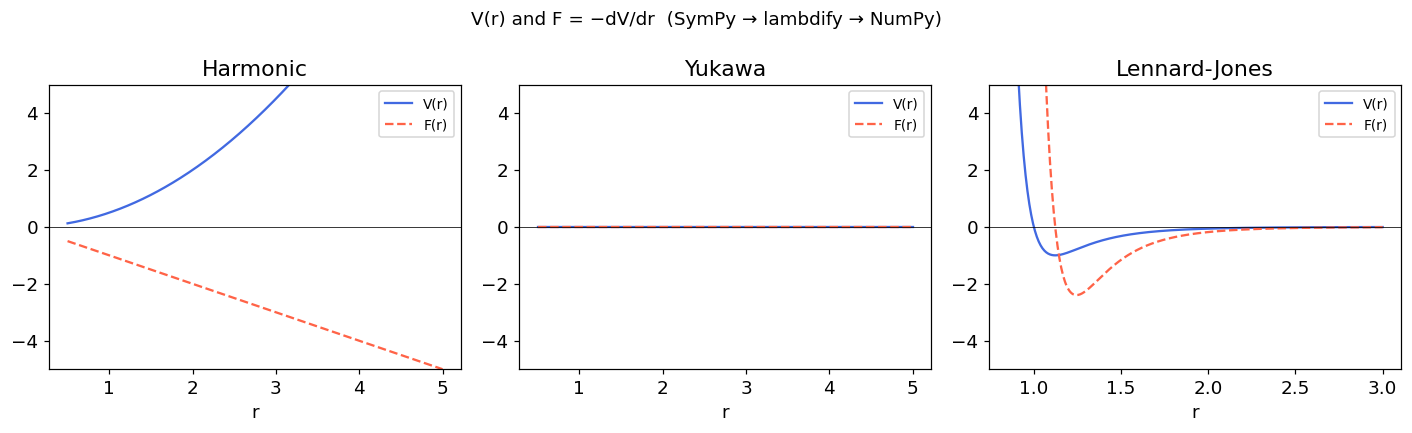

In [3]:
r, m1, m2, q1, q2, k, omega, alpha = sp.symbols(
    'r m_1 m_2 q_1 q_2 k omega alpha', positive=True
)

# ── potential energy library ───────────────────────────────────────────
potentials = [
    ('Gravitational',  -G * m1 * m2 / r),
    ('Coulomb',         k_e * q1 * q2 / r),
    ('Harmonic',        sp.Rational(1,2) * k * r**2),
    ('Yukawa',          k_e * q1 * q2 * sp.exp(-alpha * r) / r),
    ('Lennard-Jones',   4 * eps0 * ((1/r)**12 - (1/r)**6)),   # using eps0 as ε_LJ
]

print('Force F = −dV/dr for each potential:\n')
forces = []
for name, V in potentials:
    F = -sp.diff(V, r)
    F_simplified = sp.simplify(F)
    forces.append((name, V, F_simplified))
    display(Math(rf'\text{{{name}}}: \quad V = {sp.latex(V)} \implies F = {sp.latex(F_simplified)}'))
    print()

# ── lambdify + NumPy vectorization ────────────────────────────────────
r_vals = np.linspace(0.5, 5.0, 400)
subs   = {G: 6.674e-11, m1: 1.0, m2: 1.0,
          k_e: 8.988e9, q1: 1.602e-19, q2: 1.602e-19,
          k: 1.0, alpha: 1.0, eps0: 1.0}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_names = ['Harmonic', 'Yukawa', 'Lennard-Jones']

for ax, pname in zip(axes, plot_names):
    entry = next(x for x in forces if x[0] == pname)
    V_num = entry[1].subs(subs)
    F_num = entry[2].subs(subs)
    V_fn  = sp.lambdify(r, V_num, 'numpy')
    F_fn  = sp.lambdify(r, F_num, 'numpy')
    rv    = r_vals if pname != 'Lennard-Jones' else np.linspace(0.85, 3.0, 400)
    ax.plot(rv, V_fn(rv), label='V(r)', color='royalblue')
    ax.plot(rv, F_fn(rv), label='F(r)', color='tomato', ls='--')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(pname); ax.set_xlabel('r'); ax.legend(fontsize=9)
    ax.set_ylim(-5, 5)

plt.suptitle('V(r) and F = −dV/dr  (SymPy → lambdify → NumPy)', fontsize=12)
plt.tight_layout(); plt.show()

---
## Pattern 3 — Loop over Taylor / Laurent series expansions

**Plain English:** approximations are everywhere in physics — small angles, weak fields, non-relativistic limits.  
A SymPy loop lets you expand any expression to order $n$ and print the progression  
$n=1,2,3,\ldots$ so you can see exactly when each correction term kicks in.

── Relativistic KE ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

ValueError: x and y must have same first dimension, but have shapes (500,) and (1,)

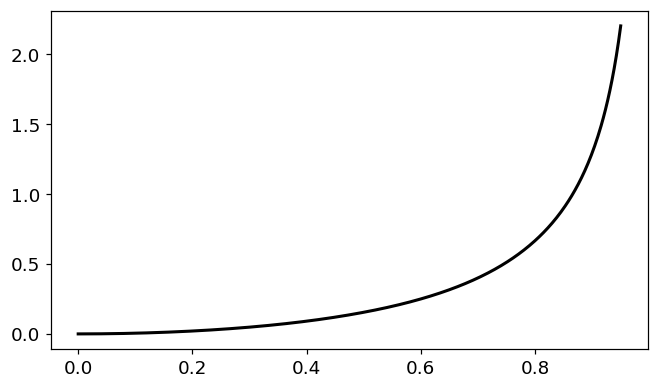

In [4]:
x, v, beta = sp.symbols('x v beta', real=True)

# ── functions to expand ────────────────────────────────────────────────
expansions = [
    ('Relativistic KE',  1/sp.sqrt(1 - beta**2) - 1,  beta, 0, r'\beta'),
    ('sin(x)/x  (sinc)', sp.sin(x)/x,                  x,    0, r'x'),
    ('Planck / classical',
     sp.exp(x) / (sp.exp(x) - 1) - 1/x,               x,    0, r'x'),
    ('1/(1-x)  geometric', 1/(1-x),                    x,    0, r'x'),
]

for fname, expr, var, pt, var_latex in expansions:
    print(f'── {fname} ──')
    for n_order in range(2, 9, 2):   # orders 2, 4, 6, 8
        s = sp.series(expr, var, pt, n_order).removeO()
        display(Math(rf'n={n_order}: \quad {sp.latex(s)}'))
    print()

# ── NumPy vectorize: compare exact vs n=2,4,6 for relativistic KE ─────
beta_vals = np.linspace(0, 0.95, 500)
gamma_exact = 1/np.sqrt(1 - beta_vals**2) - 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(beta_vals, gamma_exact, 'k', lw=2, label='exact γ−1')

colors = ['royalblue', 'seagreen', 'tomato']
for n_order, col in zip([2, 4, 6], colors):
    s_expr = sp.series(1/sp.sqrt(1 - beta**2) - 1, beta, 0, n_order).removeO()
    s_fn   = sp.lambdify(beta, s_expr, 'numpy')
    ax.plot(beta_vals, s_fn(beta_vals), '--', color=col, label=f'Taylor n={n_order}')

ax.set_xlabel(r'$\beta = v/c$'); ax.set_ylabel(r'$\gamma - 1$')
ax.set_title('Relativistic KE: exact vs Taylor series')
ax.set_ylim(-0.2, 4); ax.legend(); plt.tight_layout(); plt.show()

---
## Pattern 4 — Loop over equations and solve symbolically

**Plain English:** `sp.solve` and `sp.solveset` are your algebraic workhorses.  
Loop over a list of physics equations (dispersion relations, resonance conditions, threshold energies)  
and let SymPy hand back the closed-form solutions — then immediately vectorize them in NumPy and Torch.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

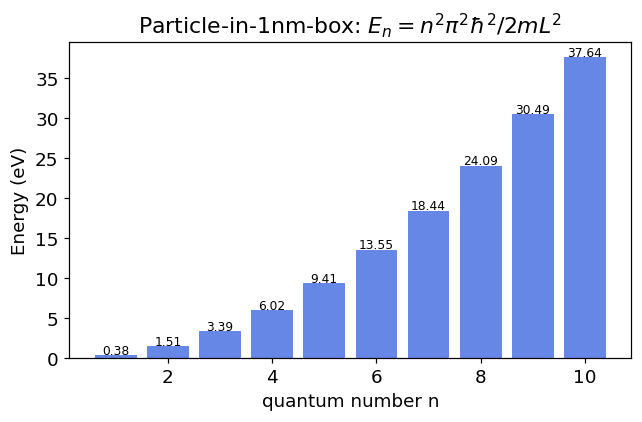

Torch E_n (eV): [ 0.376  1.506  3.388  6.022  9.41  13.55  18.443 24.089 30.488 37.639]


In [5]:
E, m, p, omega_sym, k_sym, L, n_sym, h = sp.symbols(
    'E m p omega k L n h', positive=True
)

# ── equations to solve (lhs = 0) ──────────────────────────────────────
equations = [
    ('Particle-in-box energy levels (solve for E)',
     E - (n_sym**2 * sp.pi**2 * hbar**2) / (2 * m * L**2),
     E,
     {hbar: 1.055e-34, m: 9.109e-31, L: 1e-9}),   # electron in 1 nm box

    ('Photon energy-momentum  E=pc  (solve for p)',
     E - p * c,
     p,
     {c: 2.998e8}),

    ('de Broglie wavelength  λ=h/p  (solve for p)',
     p - h / omega_sym,    # using omega as λ for brevity
     p,
     {}),

    ('Relativistic E²=(pc)²+(mc²)²  (solve for p)',
     E**2 - (p*c)**2 - (m*c**2)**2,
     p,
     {c: 2.998e8, m: 9.109e-31}),
]

solutions = []
for name, eqn, solve_for, num_subs in equations:
    sol = sp.solve(eqn, solve_for)
    solutions.append((name, solve_for, sol, num_subs))
    display(Math(rf'\text{{{name}}}'))
    for s in sol:
        display(Math(rf'\quad {sp.latex(solve_for)} = {sp.latex(s)}'))
    print()

# ── NumPy: particle-in-box, vectorize over n = 1..10 ──────────────────
name, solve_for, sol, num_subs = solutions[0]
E_sym_expr = sol[0]
E_fn = sp.lambdify(n_sym, E_sym_expr.subs(num_subs), 'numpy')

n_vals = np.arange(1, 11)
E_vals = E_fn(n_vals)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(n_vals, E_vals / 1.602e-19, color='royalblue', alpha=0.8)
ax.set_xlabel('quantum number n'); ax.set_ylabel('Energy (eV)')
ax.set_title('Particle-in-1nm-box: $E_n = n^2 \\pi^2 \\hbar^2 / 2mL^2$')
for ni, Ei in zip(n_vals, E_vals / 1.602e-19):
    ax.text(ni, Ei + 0.1, f'{Ei:.2f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

# ── Torch: same energy levels as tensor ───────────────────────────────
n_t = torch.arange(1, 11, dtype=torch.float64)
hbar_si = 1.055e-34; m_si = 9.109e-31; L_si = 1e-9
E_t = (n_t**2 * np.pi**2 * hbar_si**2) / (2 * m_si * L_si**2)
print('Torch E_n (eV):', (E_t / 1.602e-19).numpy().round(3))

---
## Pattern 5 — Loop over wave equations: dispersion relations

**Plain English:** in EM, acoustics, and QM, the *dispersion relation* $\omega(k)$ tells you  
how fast each frequency component travels.  Different media give different $\omega(k)$ curves.  
Loop with SymPy to get group velocity $v_g = d\omega/dk$ and phase velocity $v_p = \omega/k$  
symbolically, then plot all of them at once.

Medium                               v_phase = ω/k                        v_group = dω/dk
--------------------------------------------------------------------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

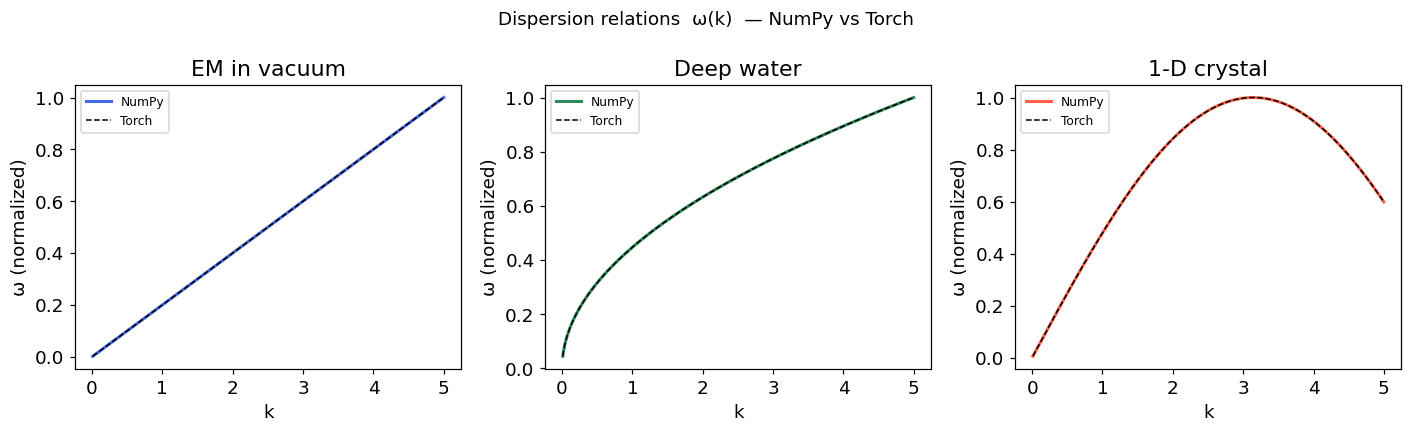

In [6]:
k_s, omega_s, c_s, m_s, a_s2 = sp.symbols('k omega c m a', positive=True)

# ── dispersion relations  ω(k) ────────────────────────────────────────
dispersion_relations = [
    ('EM in vacuum',          c_s * k_s),
    ('EM in plasma',          sp.sqrt(c_s**2 * k_s**2 + omega_s**2)),   # ω_p = omega_s
    ('Relativistic QM',       sp.sqrt((c_s * k_s)**2 + (m_s * c_s**2 / hbar)**2)),
    ('1-D crystal (tight-binding)', 2 * omega_s * sp.Abs(sp.sin(k_s * a_s2 / 2))),
    ('Deep water gravity wave', sp.sqrt(9.81 * k_s)),
]

print(f'{"Medium":35}  {"v_phase = ω/k":35}  {"v_group = dω/dk"}')
print('-'*110)
vg_list = []
for name, omega_k in dispersion_relations:
    v_phase = sp.simplify(omega_k / k_s)
    v_group = sp.simplify(sp.diff(omega_k, k_s))
    vg_list.append((name, omega_k, v_group))
    display(Math(
        rf'\text{{{name}}}: \quad '
        rf'v_p = {sp.latex(v_phase)}, \quad '
        rf'v_g = {sp.latex(v_group)}'
    ))
    print()

# ── NumPy + Torch: plot ω(k) for the non-parametric ones ─────────────
k_vals = np.linspace(0.01, 5.0, 500)
k_t    = torch.tensor(k_vals, dtype=torch.float64)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_cases = [
    ('EM in vacuum',    lambda k: 3e8 * k,          'royalblue'),
    ('Deep water',      lambda k: np.sqrt(9.81 * k), 'seagreen'),
    ('1-D crystal',     lambda k: 2 * np.abs(np.sin(k / 2)), 'tomato'),
]
torch_cases = [
    lambda k: 3e8 * k,
    lambda k: torch.sqrt(9.81 * k),
    lambda k: 2 * torch.abs(torch.sin(k / 2)),
]

for ax, (name, fn_np, col), fn_t in zip(axes, plot_cases, torch_cases):
    omega_np = fn_np(k_vals)
    omega_t  = fn_t(k_t).numpy()
    ax.plot(k_vals, omega_np / omega_np.max(), color=col,    lw=2,   label='NumPy')
    ax.plot(k_vals, omega_t  / omega_t.max(),  color='k', lw=1, ls='--', label='Torch')
    ax.set_title(name); ax.set_xlabel('k'); ax.set_ylabel('ω (normalized)')
    ax.legend(fontsize=8)

plt.suptitle('Dispersion relations  ω(k)  — NumPy vs Torch', fontsize=12)
plt.tight_layout(); plt.show()

---
## Pattern 6 — Loop over ∂/∂x, ∂²/∂x², ∂ⁿ/∂xⁿ  (operator ladder)

**Plain English:** QM operators, Green's functions, and transfer functions all live in derivative space.  
Loop `n` from 0 to N and apply $\partial^n/\partial x^n$ to a wavefunction — this is exactly  
how the momentum operator $\hat{p} = -i\hbar\,\partial/\partial x$ works, and how you  
build the kinetic energy operator $\hat{T} = -\hbar^2/(2m)\,\partial^2/\partial x^2$.

<IPython.core.display.Math object>


Derivatives of ψ:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Momentum operator applied:


<IPython.core.display.Math object>

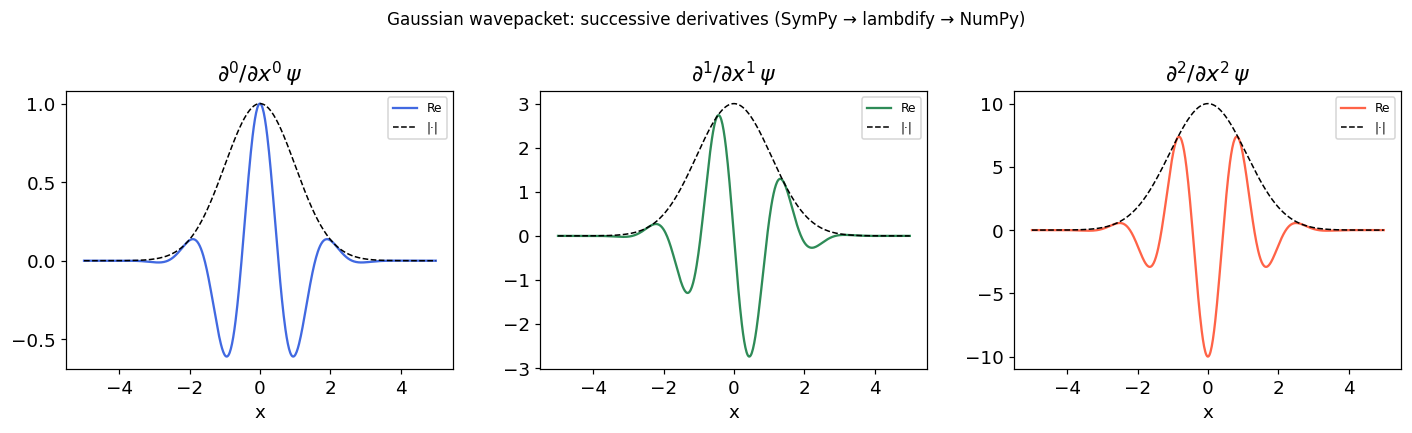

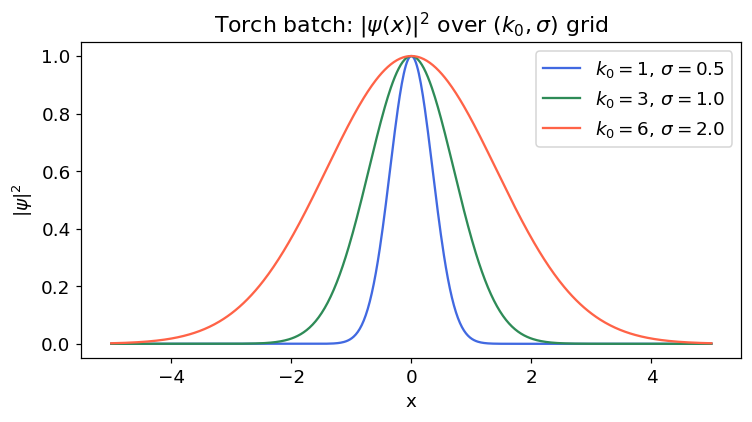

In [7]:
x_s, k0, sigma = sp.symbols('x k_0 sigma', real=True)
i_s = sp.I

# ── Gaussian wavepacket ψ(x) = exp(ik₀x) · exp(-x²/2σ²) ──────────────
psi = sp.exp(i_s * k0 * x_s) * sp.exp(-x_s**2 / (2 * sigma**2))
display(Math(rf'\psi(x) = {sp.latex(psi)}'))
print()

# ── loop: apply ∂ⁿ/∂xⁿ for n = 0 .. 4 ────────────────────────────────
print('Derivatives of ψ:')
deriv_exprs = []
for n in range(5):
    dpsi = sp.diff(psi, x_s, n)
    dpsi_s = sp.simplify(dpsi)
    deriv_exprs.append(dpsi_s)
    display(Math(rf'\partial^{n}/\partial x^{n}\,\psi = {sp.latex(dpsi_s)}'))

# ── momentum operator expectation: ⟨p⟩ = ∫ ψ* (-iħ ∂/∂x) ψ dx ────────
print('\nMomentum operator applied:')
p_op_psi = -i_s * hbar * sp.diff(psi, x_s)
p_op_simplified = sp.simplify(p_op_psi / psi)   # = ħk₀ - iħx/σ²
display(Math(rf'\hat{{p}}\,\psi / \psi = {sp.latex(p_op_simplified)}'))

# ── NumPy vectorize: plot |ψ|² and its derivatives ───────────────────
subs_num = {k0: 3.0, sigma: 1.0, hbar: 1.0}
x_vals = np.linspace(-5, 5, 600)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (n, col) in zip(axes, [(0,'royalblue'), (1,'seagreen'), (2,'tomato')]):
    fn = sp.lambdify(x_s, deriv_exprs[n].subs(subs_num), 'numpy')
    y  = fn(x_vals)
    y_re = np.real(y); y_abs = np.abs(y)
    ax.plot(x_vals, y_re,  color=col, label='Re', lw=1.5)
    ax.plot(x_vals, y_abs, color='k', label='|·|', lw=1, ls='--')
    ax.set_title(rf'$\partial^{n}/\partial x^{n}\,\psi$')
    ax.set_xlabel('x'); ax.legend(fontsize=8)

plt.suptitle('Gaussian wavepacket: successive derivatives (SymPy → lambdify → NumPy)', fontsize=11)
plt.tight_layout(); plt.show()

# ── Torch: batch |ψ|² over (k₀, σ) grid ──────────────────────────────
x_t   = torch.linspace(-5, 5, 600, dtype=torch.float64)
k0_t  = torch.tensor([1.0, 3.0, 6.0], dtype=torch.float64)
sig_t = torch.tensor([0.5, 1.0, 2.0], dtype=torch.float64)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['royalblue', 'seagreen', 'tomato']
for k0v, sv, col in zip(k0_t, sig_t, colors):
    psi_t = torch.exp(1j * k0v * x_t) * torch.exp(-x_t**2 / (2 * sv**2))
    ax.plot(x_t.numpy(), psi_t.abs().numpy()**2, color=col,
            label=rf'$k_0={k0v:.0f},\,\sigma={sv}$')
ax.set_xlabel('x'); ax.set_ylabel(r'$|\psi|^2$')
ax.set_title(r'Torch batch: $|\psi(x)|^2$ over $(k_0, \sigma)$ grid')
ax.legend(); plt.tight_layout(); plt.show()

---
## Pattern 7 — Loop over Coulomb interactions in a charge array

**Plain English:** the Coulomb constant $k_e = 1/(4\pi\epsilon_0) \approx 8.99\times10^9\,\text{N m}^2\text{C}^{-2}$  
appears in every pairwise electrostatic energy.  Loop with SymPy to get the closed-form  
total energy for $N$ charges, then use NumPy/Torch to compute it numerically for big arrays.

Pairwise Coulomb terms (SymPy loop):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


NumPy: total Coulomb energy for 500 charges on unit circle = 5.8191e-23 J
Torch: total Coulomb energy                                = 5.8191e-23 J
Relative difference NumPy vs Torch: 0.00e+00


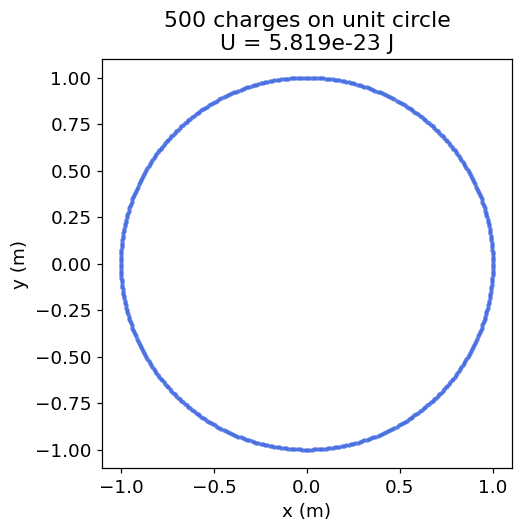

In [8]:
# ── SymPy: pairwise Coulomb energy for N=3 charges ────────────────────
N_charges = 3
q_syms = sp.symbols(f'q1:{N_charges+1}', real=True)
r_syms = [[sp.Symbol(f'r_{min(i,j)+1}{max(i,j)+1}', positive=True)
           for j in range(N_charges)] for i in range(N_charges)]

k_e_sym = sp.Symbol('k_e', positive=True)
U_total = sp.Integer(0)
pair_terms = []

for i in range(N_charges):
    for j in range(i+1, N_charges):
        U_ij = k_e_sym * q_syms[i] * q_syms[j] / r_syms[i][j]
        pair_terms.append(((i+1, j+1), U_ij))
        U_total += U_ij

print('Pairwise Coulomb terms (SymPy loop):')
for (i,j), term in pair_terms:
    display(Math(rf'U_{{{i}{j}}} = {sp.latex(term)}'))
display(Math(rf'U_{{\text{{total}}}} = {sp.latex(U_total)}'))

# ── NumPy: N=500 charges on a circle, compute total U ─────────────────
N = 500
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
pos   = np.stack([np.cos(theta), np.sin(theta)], axis=1)  # (N,2)
charges = np.ones(N) * 1.602e-19   # all +e
k_e_val = 8.988e9

# vectorized pairwise distances via broadcasting
diff_pos = pos[:, None, :] - pos[None, :, :]     # (N,N,2)
dist     = np.sqrt((diff_pos**2).sum(-1))         # (N,N)
np.fill_diagonal(dist, np.inf)                    # avoid self-interaction

qi_qj = charges[:, None] * charges[None, :]      # (N,N)
U_matrix = k_e_val * qi_qj / dist
U_np = 0.5 * U_matrix.sum()   # factor 1/2 for double-counting
print(f'\nNumPy: total Coulomb energy for {N} charges on unit circle = {U_np:.4e} J')

# ── Torch: same computation on GPU-ready tensor ───────────────────────
pos_t = torch.tensor(pos, dtype=torch.float64)
q_t   = torch.tensor(charges, dtype=torch.float64)

diff_t = pos_t.unsqueeze(0) - pos_t.unsqueeze(1)   # (N,N,2)
dist_t = diff_t.norm(dim=-1)                         # (N,N)
dist_t.fill_diagonal_(float('inf'))

qi_qj_t = q_t.unsqueeze(0) * q_t.unsqueeze(1)
U_t = 0.5 * (k_e_val * qi_qj_t / dist_t).sum().item()
print(f'Torch: total Coulomb energy                                = {U_t:.4e} J')
print(f'Relative difference NumPy vs Torch: {abs(U_np - U_t)/abs(U_np):.2e}')

# ── plot the charge distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pos[:,0], pos[:,1], s=4, color='royalblue', alpha=0.7)
ax.set_aspect('equal'); ax.set_title(f'{N} charges on unit circle\nU = {U_np:.3e} J')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout(); plt.show()

---
## Pattern 8 — Loop over integration: partition functions

**Plain English:** statistical mechanics lives in integrals.  The partition function  
$Z = \int e^{-E/k_BT}\,g(E)\,dE$ is what connects microscopic physics to thermodynamics.  
Loop with SymPy to compute $Z$, $\langle E\rangle$, $C_V$ analytically for  
different density-of-states $g(E)$, then vectorize over temperature $T$.

Partition function Z and mean energy ⟨E⟩ (SymPy loop):



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

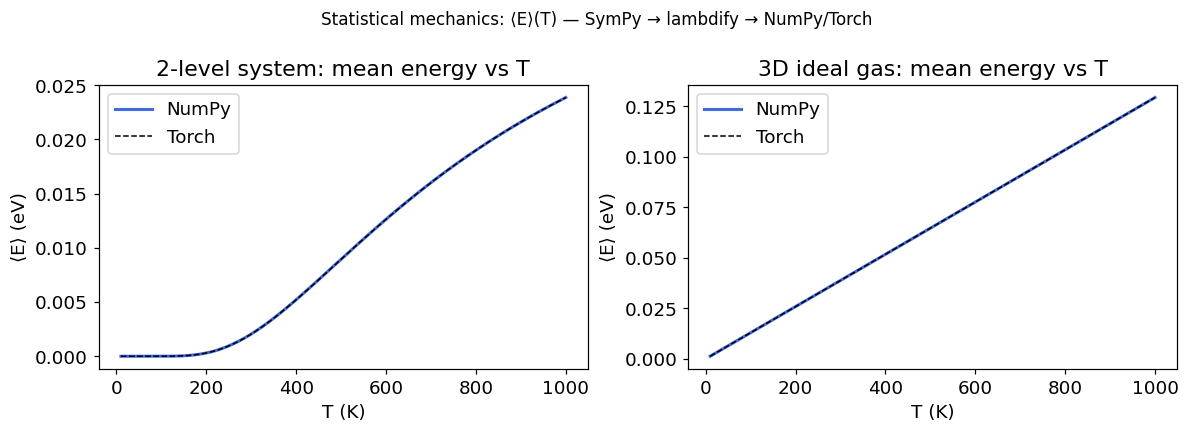

In [9]:
T_s, E_s, beta_s = sp.symbols('T E beta', positive=True)
k_B_sym = sp.Symbol('k_B', positive=True)

# ── density of states models ──────────────────────────────────────────
dos_models = [
    ('2-level system   g(E)=δ(E-E₀)', None,     'discrete'),
    ('3D ideal gas     g(E)∝√E',       sp.sqrt(E_s), 'continuous'),
    ('2D electron gas  g(E)=const',    sp.Integer(1), 'continuous'),
    ('1D phonon        g(E)∝1/√E',     1/sp.sqrt(E_s), 'continuous'),
]

E0_s = sp.Symbol('E_0', positive=True)

print('Partition function Z and mean energy ⟨E⟩ (SymPy loop):\n')
mean_energies = []
for name, g_E, kind in dos_models:
    if kind == 'discrete':
        # two-level: E=0 and E=E₀
        Z_expr = 1 + sp.exp(-E0_s / (k_B_sym * T_s))
        E_mean = E0_s * sp.exp(-E0_s / (k_B_sym * T_s)) / Z_expr
    else:
        integrand = g_E * sp.exp(-E_s / (k_B_sym * T_s))
        Z_expr    = sp.integrate(integrand, (E_s, 0, sp.oo))
        Z_expr    = sp.simplify(Z_expr)
        E_integrand = E_s * g_E * sp.exp(-E_s / (k_B_sym * T_s))
        E_mean    = sp.simplify(sp.integrate(E_integrand, (E_s, 0, sp.oo)) / Z_expr)

    C_V = sp.simplify(sp.diff(E_mean, T_s))
    mean_energies.append((name, E_mean, C_V))
    display(Math(rf'\text{{{name}}}'))
    display(Math(rf'\langle E \rangle = {sp.latex(E_mean)}, \quad C_V = {sp.latex(C_V)}'))
    print()

# ── NumPy + Torch: plot ⟨E⟩(T) for 2-level and 3D gas ────────────────
T_vals = np.linspace(10, 1000, 400)
T_t    = torch.tensor(T_vals, dtype=torch.float64)
kB     = 1.381e-23; E0_val = 0.1 * 1.602e-19   # 0.1 eV

# two-level NumPy
E_2level_np = E0_val * np.exp(-E0_val/(kB*T_vals)) / (1 + np.exp(-E0_val/(kB*T_vals)))
# 3D gas  ⟨E⟩ = (3/2) k_B T
E_3d_np     = 1.5 * kB * T_vals

# Torch
E_2level_t  = E0_val * torch.exp(-E0_val/(kB*T_t)) / (1 + torch.exp(-E0_val/(kB*T_t)))
E_3d_t      = 1.5 * kB * T_t

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (E_np, E_t, title) in zip(axes, [
        (E_2level_np, E_2level_t, '2-level system'),
        (E_3d_np,     E_3d_t,     '3D ideal gas')]):
    ax.plot(T_vals, E_np/1.602e-19, color='royalblue', lw=2, label='NumPy')
    ax.plot(T_vals, E_t.numpy()/1.602e-19, 'k--', lw=1, label='Torch')
    ax.set_xlabel('T (K)'); ax.set_ylabel('⟨E⟩ (eV)')
    ax.set_title(f'{title}: mean energy vs T'); ax.legend()

plt.suptitle('Statistical mechanics: ⟨E⟩(T) — SymPy → lambdify → NumPy/Torch', fontsize=11)
plt.tight_layout(); plt.show()

---
## Summary: the eight SymPy loop patterns

| # | Pattern | SymPy tool | NumPy/Torch tool |
|---|---------|-----------|----------------|
| 1 | Loop over constants | `sp.symbols`, `display(Math(...))` | `np.linspace` + plot |
| 2 | Loop over potentials, differentiate | `sp.diff` | `sp.lambdify` → vectorized array |
| 3 | Loop over Taylor orders | `sp.series` | `sp.lambdify` → compare exact |
| 4 | Loop over equations, solve | `sp.solve` | `sp.lambdify` → `torch.tensor` |
| 5 | Loop over dispersion relations | `sp.diff` for $v_g$, $v_p$ | `torch` vs `numpy` overlay |
| 6 | Loop over derivative order $n$ | `sp.diff(f, x, n)` | `np.real`, `torch.exp(1j·)` |
| 7 | Loop over charge pairs | pairwise $U_{ij}$ | broadcasting `dist_t.norm` |
| 8 | Loop over DOS models, integrate | `sp.integrate` | `torch` temperature sweep |

**Core workflow every time:**  
`sp.symbols` → SymPy loop → `sp.simplify` / `sp.solve` / `sp.integrate` → `sp.lambdify` → `numpy` or `torch`